# ════════════════════════════════════════════════════════════════════════════
# MULTI-PATCH EBOLA FITTING WITH FLOWMINDER MOBILITY
# Complete Jupyter Notebook
# ════════════════════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════════════════════
# SECTION 0: IMPORTS
# ════════════════════════════════════════════════════════════════════════════


In [77]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
from scipy.special import gammaln
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional
import warnings
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("✓ All imports successful")


✓ All imports successful



# ════════════════════════════════════════════════════════════════════════════
# SECTION 1: DATA LOADING FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════


In [78]:
def load_multipath_ebola_data(csv_file: str) -> Tuple[Dict, np.ndarray, np.ndarray, list, list]:
    """
    Load multi-patch Ebola data from CSV.
    
    CSV format should have columns:
      - Date
      - Patch (or Region/Location)
      - smoothed_confirmed_cases
      - smoothed_confirmed_deaths
    
    Returns
    -------
    data_dict : dict
    obs_cases : ndarray, shape (n_patches, n_days)
    obs_deaths : ndarray, shape (n_patches, n_days)
    patch_names : list of str
    all_dates : list of datetime
    """
    
    df = pd.read_csv(csv_file)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Identify patch column
    patch_col = [c for c in df.columns if c.lower() in ['nom']]
    if not patch_col:
        # If no patch column, create one
        df['Patch'] = 'Patch_0'
        patch_col = ['Patch']
    
    patch_col = patch_col[0]
    
    # Get unique patches
    patches = df[patch_col].unique()
    patch_names = list(patches)
    n_patches = len(patch_names)
    
    # Get time range
    all_dates = sorted(df['Date'].unique())
    n_days = len(all_dates)
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    
    # Initialize arrays
    obs_cases = np.zeros((n_patches, n_days))
    obs_deaths = np.zeros((n_patches, n_days))
    
    # Fill data
    data_dict = {}
    for patch_idx, patch in enumerate(patch_names):
        patch_df = df[df[patch_col] == patch].copy()
        patch_df = patch_df.sort_values('Date')
        
        cases = []
        deaths = []
        dates = []
        
        for _, row in patch_df.iterrows():
            date = row['Date']
            day_idx = date_to_idx[date]
            
            obs_cases[patch_idx, day_idx] = row['smoothed_confirmed_cases']
            obs_deaths[patch_idx, day_idx] = row['smoothed_confirmed_deaths']
            
            cases.append(row['smoothed_confirmed_cases'])
            deaths.append(row['smoothed_confirmed_deaths'])
            dates.append(date)
        
        data_dict[patch] = {
            'cases': np.array(cases),
            'deaths': np.array(deaths),
            'dates': dates
        }
    
    return data_dict, obs_cases, obs_deaths, patch_names, all_dates

# ════════════════════════════════════════════════════════════════════════════
# FUNCTION TO LOAD POPULATION DATA
# ════════════════════════════════════════════════════════════════════════════

def load_population_data(csv_file: str, patch_names: list) -> np.ndarray:
    """
    Load population data from CSV file.
    
    Expected CSV format:
    Patch,Population
    Aba,1000000
    Adi,800000
    Bua,500000
    Handles flexible column naming:
    - Patch columns: 'Patch', 'Region', 'Location', 'District', 'Area', 'Zone'
    - Population columns: 'Population', 'Pop', 'Total_Pop', 'N_Pop', 'Inhabitants'
    
    Parameters
    ----------
    csv_file : str
        Path to CSV with population data
    patch_names : list
        Names of patches (from epidemiological data)
        
    Returns
    -------
    N_patches : ndarray, shape (n_patches,)
        Population per patch, in same order as patch_names
    """
    
    # Read CSV
    df = pd.read_csv(csv_file)
    
    # Identify columns (flexible naming)
    patch_col = None
    pop_col = None
    
    # Find patch/region column
    for col in df.columns:
        if col.lower() in ['patch', 'region', 'location', 'district', 'area', 'zone']:
            patch_col = col
            break
    
    # Find population column
    for col in df.columns:
        if col.lower() in ['count', 'pop', 'total_pop', 'n_pop', 'inhabitants', 'residents']:
            pop_col = col
            break
    
    if patch_col is None or pop_col is None:
        print(f"ERROR: Could not identify columns in {csv_file}")
        print(f"Available columns: {df.columns.tolist()}")
        raise ValueError("CSV must have columns for [Patch/Region] and [Population/Pop]")
    
    print(f"\n✓ Population data loaded")
    print(f"  File: {csv_file}")
    print(f"  Patch column: '{patch_col}'")
    print(f"  Population column: '{pop_col}'")
    
    # Create mapping
    pop_dict = dict(zip(df[patch_col], df[pop_col]))
    
    print(f"  Patches in file: {list(pop_dict.keys())}")
    
    # Match with patch_names and extract populations
    N_patches = np.zeros(len(patch_names))
    unmatched = []
    
    for i, patch in enumerate(patch_names):
        if patch in pop_dict:
            N_patches[i] = pop_dict[patch]
        else:
            # Try case-insensitive match
            matched = False
            for key in pop_dict.keys():
                if key.lower() == patch.lower():
                    N_patches[i] = pop_dict[key]
                    print(f"  ✓ Matched '{patch}' to '{key}' (case-insensitive)")
                    matched = True
                    break
            
            if not matched:
                print(f"  ⚠ No match found for '{patch}'")
                unmatched.append(patch)
    
    # Check for unmatched
    if unmatched:
        raise ValueError(f"Could not match patches: {unmatched}\n"
                        f"Available in file: {list(pop_dict.keys())}")
    
    # Check for zeros
    if np.any(N_patches == 0):
        print("\n⚠ WARNING: Some patches have zero population!")
        for i, patch in enumerate(patch_names):
            if N_patches[i] == 0:
                print(f"  {patch}: {N_patches[i]}")
    
    return N_patches.astype(float)



# ════════════════════════════════════════════════════════════════════════════
# SECTION 2: FLOWMINDER MOBILITY MATRIX LOADING
# ════════════════════════════════════════════════════════════════════════════


In [79]:
def load_flowminder_matrix_from_csv(csv_file: str) -> Tuple[np.ndarray, list]:
    """
    Load Flowminder OD matrix from matrix-format CSV.
    
    Expected CSV format:
    nom,Aba,Adi,Bua,...
    Aba,0.0,371.0,100.0,...
    Adi,1130.0,0.0,200.0,...
    Returns
    -------
    U : ndarray, shape (n_patches, n_patches)
        Row-stochastic mobility matrix
    patch_names : list
    """
    
    df = pd.read_csv(csv_file, index_col=0)
    
    patch_names = df.index.tolist()
    n_patches = len(patch_names)
    
    flow_matrix = df.values.astype(float)
    
    assert flow_matrix.shape == (n_patches, n_patches), \
        f"Flow matrix must be square. Got {flow_matrix.shape}"
    
    # Row-normalize
    row_sums = flow_matrix.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-10)
    U = flow_matrix / row_sums
    
    print(f"✓ Loaded mobility matrix from {csv_file}")
    print(f"  Patches: {patch_names}")
    print(f"  Shape: {U.shape}")
    
    return U, patch_names


def load_flowminder_inflow_outflow(inflow_csv: str, outflow_csv: str, 
                                   method: str = 'average') -> Tuple[np.ndarray, list]:
    """
    Load Flowminder matrices from separate inflow and outflow CSVs.
    
    Parameters
    ----------
    inflow_csv : str
    outflow_csv : str
    method : str
        'average': (inflow + outflow) / 2
        'inflow': use only inflow
        'outflow': use only outflow
        'symmetric': (inflow + outflow.T) / 2
        
    Returns
    -------
    U : ndarray, shape (n_patches, n_patches)
    patch_names : list
    """
    
    inflow_df = pd.read_csv(inflow_csv, index_col=0)
    outflow_df = pd.read_csv(outflow_csv, index_col=0)
    
    patch_names = inflow_df.index.tolist()
    inflow = inflow_df.values.astype(float)
    outflow = outflow_df.values.astype(float)
    
    if method == 'average':
        flow_matrix = (inflow + outflow) / 2
    elif method == 'inflow':
        flow_matrix = inflow
    elif method == 'outflow':
        flow_matrix = outflow
    elif method == 'symmetric':
        flow_matrix = (inflow + outflow.T) / 2
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Row-normalize
    row_sums = flow_matrix.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-10)
    U = flow_matrix / row_sums
    
    print(f"✓ Loaded mobility from inflow/outflow (method: {method})")
    print(f"  Inflow: {inflow_csv}")
    print(f"  Outflow: {outflow_csv}")
    print(f"  Patches: {patch_names}")
    print(f"  Shape: {U.shape}")
    
    return U, patch_names


def validate_mobility_matrix(U: np.ndarray, tolerance: float = 1e-6) -> bool:
    """
    Validate that mobility matrix is row-stochastic.
    """
    
    print("\n─ Validating mobility matrix...")
    
    if U.ndim != 2 or U.shape[0] != U.shape[1]:
        print("  ✗ Must be square matrix")
        return False
    
    if not np.all(U >= 0):
        print("  ✗ Contains negative entries")
        return False
    
    row_sums = U.sum(axis=1)
    is_stochastic = np.allclose(row_sums, 1.0, atol=tolerance)
    
    if not is_stochastic:
        print(f"  ✗ Not row-stochastic. Row sums: {row_sums}")
        return False
    
    print(f"  ✓ Valid row-stochastic matrix")
    print(f"    Shape: {U.shape}")
    print(f"    All entries ≥ 0: {np.all(U >= 0)}")
    print(f"    Row sums = 1.0: {is_stochastic}")
    
    return True


def print_mobility_matrix(U: np.ndarray, patch_names: list = None):
    """Pretty-print the mobility matrix."""
    
    n = U.shape[0]
    
    if patch_names is None:
        patch_names = [f"Patch_{i}" for i in range(n)]
    
    print("\n" + "="*80)
    print("MOBILITY MATRIX (U[i,j] = fraction of patch i residents in patch j)")
    print("="*80)
    
    df_u = pd.DataFrame(U, index=patch_names, columns=patch_names)
    print(df_u.round(4).to_string())
    
    print("\n" + "─"*80)
    print("INTERPRETATION:")
    for i, patch in enumerate(patch_names):
        print(f"\n{patch} residents:")
        for j, dest in enumerate(patch_names):
            pct = U[i, j] * 100
            if pct > 0.1:
                print(f"  {pct:5.1f}% in {dest}", end="")
        print()
    print("="*80)




# ════════════════════════════════════════════════════════════════════════════
# SECTION 3: METAPOPULATION EBOLA MODEL
# ════════════════════════════════════════════════════════════════════════════


In [80]:
class MetapopulationEbola:
    """
    Multi-patch Ebola model with mobility.
    
    State: [S_1, E_1, Id_1, Ind_1, F_1, R_1, Dd_1, Dnd_1, S_2, ...]
    """
    
    def __init__(self, n_patches: int, N_patches: np.ndarray, 
                 U_mobility: np.ndarray, r_isolation: float = 1.0):
        """
        Parameters
        ----------
        n_patches : int
        N_patches : ndarray, shape (n,)
            Population per patch
        U_mobility : ndarray, shape (n, n)
            Row-stochastic mobility matrix
        r_isolation : float
            Isolation parameter
        """
        self.n = n_patches
        self.N = N_patches.astype(float)
        self.U = U_mobility.astype(float)
        self.r = r_isolation
        
        self.compartments = ['S', 'E', 'Id', 'Ind', 'F', 'R', 'Dd', 'Dnd']
        self.n_comp = 8
    
    def compute_effective_population(self) -> np.ndarray:
        """Effective population per patch (accounting for inflows)."""
        N_e = self.U.T @ self.N
        return N_e
    
    def compute_force_of_infection(self, y: np.ndarray, beta_Id: float, 
                                   beta_Ind: float, beta_F: float) -> np.ndarray:
        """
        Compute force of infection per patch.
        
        Accounts for infectious from all patches (via mobility).
        """
        
        # Extract infectious compartments
        Id = y[2::self.n_comp]
        Ind = y[3::self.n_comp]
        F = y[4::self.n_comp]
        
        # Effective infectious (inflow from other patches)
        Id_e = self.U.T @ Id
        Ind_e = self.U.T @ Ind
        F_e = self.U.T @ F
        
        # Effective population
        N_e = self.compute_effective_population()
        N_e = np.maximum(N_e, 1e-6)
        
        # Force of infection
        lam = (self.r * beta_Id * Id_e + beta_Ind * Ind_e + beta_F * F_e) / N_e
        
        return lam
    
    def __call__(self, t: float, y: np.ndarray, beta_Id: float, beta_Ind: float, 
                 beta_F: float, alpha: float, gamma_i: float, delta1: float, 
                 mu: float, gamma_f: float):
        """RHS of ODE system."""
        
        dydt = np.zeros_like(y)
        
        # Compute force of infection
        lam = self.compute_force_of_infection(y, beta_Id, beta_Ind, beta_F)
        
        # Integrate each patch
        for i in range(self.n):
            idx = i * self.n_comp
            S, E, Id, Ind, F, R, Dd, Dnd = y[idx:idx+self.n_comp]
            
            # ODEs
            dydt[idx] = -S * lam[i]
            dydt[idx+1] = S * lam[i] - alpha * E
            dydt[idx+2] = delta1 * alpha * E - (gamma_i + mu) * Id
            dydt[idx+3] = (1 - delta1) * alpha * E - (gamma_i + mu) * Ind
            dydt[idx+4] = mu * Ind - gamma_f * F
            dydt[idx+5] = gamma_i * (Id + Ind) + gamma_f * F
            dydt[idx+6] = mu * Id
            dydt[idx+7] = gamma_f * F
        
        return dydt
    
    def run(self, t_span: Tuple[float, float], y0: np.ndarray, t_eval: np.ndarray,
            beta_Id: float, beta_Ind: float, beta_F: float, alpha: float, 
            gamma_i: float, delta1: float, mu: float, gamma_f: float):
        """Integrate ODE system."""
        
        def rhs(t, y):
            return self.__call__(t, y, beta_Id, beta_Ind, beta_F, alpha, 
                               gamma_i, delta1, mu, gamma_f)
        
        sol = solve_ivp(rhs, t_span, y0, method='RK45',
                       t_eval=t_eval, rtol=1e-8, atol=1e-10)
        
        return sol if sol.success else None




# ════════════════════════════════════════════════════════════════════════════
# SECTION 4: LIKELIHOOD FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════


In [81]:
def pnll_multipatch(obs: np.ndarray, pred: np.ndarray) -> float:
    """Poisson NLL for multi-patch data."""
    pred = np.maximum(np.asarray(pred, float), 1e-9)
    obs = np.asarray(obs, float)
    return -np.sum(obs * np.log(pred) - pred)


def nb_nll_multipatch(obs: np.ndarray, pred: np.ndarray, k: float = 10.0) -> float:
    """Negative Binomial NLL for multi-patch data."""
    obs = np.asarray(obs, float)
    pred = np.maximum(np.asarray(pred, float), 1e-9)
    
    loglik = (
        gammaln(obs + k)
        - gammaln(k)
        - gammaln(obs + 1)
        + k * np.log(k / (k + pred))
        + obs * np.log(pred / (k + pred))
    )
    
    return -np.sum(loglik)


def gaussian_nll_multipatch(obs: np.ndarray, pred: np.ndarray) -> float:
    """Gaussian NLL for multi-patch data."""
    obs = np.asarray(obs, float)
    pred = np.asarray(pred, float)
    
    residuals = obs - pred
    sigma = np.std(residuals)
    sigma = max(sigma, 1e-6)
    n = obs.size
    
    return n * np.log(sigma) + np.sum(residuals**2) / (2 * sigma**2)


def mse_multipatch(obs: np.ndarray, pred: np.ndarray) -> float:
    """MSE for multi-patch data."""
    obs = np.asarray(obs, float)
    pred = np.asarray(pred, float)
    return np.mean((obs - pred)**2)




# ════════════════════════════════════════════════════════════════════════════
# SECTION 5: MODEL BUILDING AND OBJECTIVE FUNCTION
# ════════════════════════════════════════════════════════════════════════════



In [82]:
def build_multipath_model(params: np.ndarray, n_patches: int, N_patches: np.ndarray,
                         U_mobility: np.ndarray, r: float,
                         use_patch_specific: bool = False) -> Tuple[MetapopulationEbola, np.ndarray, bool]:
    """
    Unpack parameters and build initial conditions.
    """
    
    if not use_patch_specific:
        # Global parameters
        bId, bInd, bF, alph, gi, d1, mu, gf = params[:8]
        
        # Initial conditions per patch
        log_E0 = params[8:8+n_patches]
        log_Id0 = params[8+n_patches:8+2*n_patches]
        log_Ind0 = params[8+2*n_patches:8+3*n_patches]
        
        E0 = np.exp(log_E0)
        Id0 = np.exp(log_Id0)
        Ind0 = np.exp(log_Ind0)
        
        # Check validity
        S0 = N_patches - E0 - Id0 - Ind0
        if np.any(S0 <= 0) or np.any(np.isnan(S0)):
            return None, None, False
        
        # Build model
        model = MetapopulationEbola(n_patches, N_patches, U_mobility, r_isolation=r)
        
        # Initial state vector
        y0 = np.zeros(8 * n_patches)
        for i in range(n_patches):
            idx = i * 8
            y0[idx] = S0[i]
            y0[idx+1] = E0[i]
            y0[idx+2] = Id0[i]
            y0[idx+3] = Ind0[i]
            y0[idx+4:idx+8] = 0
        
        # Store parameters
        model.beta_Id = bId
        model.beta_Ind = bInd
        model.beta_F = bF
        model.alpha = alph
        model.gamma_i = gi
        model.delta1 = d1
        model.mu = mu
        model.gamma_f = gf
        
        return model, y0, True


def objective(params: np.ndarray, n_patches: int, N_patches: np.ndarray,
              U_mobility: np.ndarray, obs_cases: np.ndarray, obs_deaths: np.ndarray,
              n_days: int, r: float = 1.0, likelihood: str = 'nb', 
              likelihood_k: float = 10.0, use_patch_specific: bool = False) -> float:
    """
    Objective function for multi-patch fitting.
    """
    
    model, y0, ok = build_multipath_model(params, n_patches, N_patches, U_mobility, r,
                                         use_patch_specific)
    if not ok:
        return 1e12
    
    t_eval = np.arange(n_days, dtype=float)
    
    sol = model.run((0., float(n_days-1)), y0, t_eval,
                   model.beta_Id, model.beta_Ind, model.beta_F,
                   model.alpha, model.gamma_i, model.delta1,
                   model.mu, model.gamma_f)
    
    if sol is None:
        return 1e12
    
    if np.any(np.isnan(sol.y)):
        return 1e12

    if np.any(np.isinf(sol.y)):
        return 1e12
    
    # Extract predictions
    E_all = sol.y[1::8]
    Id_all = sol.y[2::8]
    
    pred_cases = model.delta1 * model.alpha * E_all
    pred_deaths = model.mu * Id_all
    
    if np.any(np.isnan(pred_cases)) or np.any(np.isnan(pred_deaths)):
        return 1e12

    if np.any(pred_cases < 0) or np.any(pred_deaths < 0):
        return 1e12
    
    # Compute likelihoods
    if likelihood == 'nb':
        nll_cases = nb_nll_multipatch(obs_cases, pred_cases, k=likelihood_k)
        nll_deaths = nb_nll_multipatch(obs_deaths, pred_deaths, k=likelihood_k)
    elif likelihood == 'poisson':
        nll_cases = pnll_multipatch(obs_cases, pred_cases)
        nll_deaths = pnll_multipatch(obs_deaths, pred_deaths)
    elif likelihood == 'gaussian':
        nll_cases = gaussian_nll_multipatch(obs_cases, pred_cases)
        nll_deaths = gaussian_nll_multipatch(obs_deaths, pred_deaths)
    else:
        nll_cases = mse_multipatch(obs_cases, pred_cases)
        nll_deaths = mse_multipatch(obs_deaths, pred_deaths)

    if np.isnan(nll_cases):
        print("NaN in cases likelihood")

    if np.isnan(nll_deaths):
        print("NaN in deaths likelihood")

    return nll_cases + nll_deaths




# ════════════════════════════════════════════════════════════════════════════
# SECTION 6: CREATE PARAMETER BOUNDS
# ════════════════════════════════════════════════════════════════════════════



In [83]:
def create_bounds(n_patches: int, use_patch_specific: bool = False) -> list:
    """Create bounds for differential evolution."""
    
    BOUNDS = [
        (0.01, 0.5),      # beta_Id
        (0.05, 0.5),      # beta_Ind
        (0.05, 0.2),      # beta_F
        (1/21, 1/2),      # alpha
        (1/11, 1/6),      # gamma_i
        (0, 1),           # delta1
        (1/16, 1/6),      # mu
        (1/3, 1.00),      # gamma_f
    ]
    
    # Initial conditions per patch
    for i in range(n_patches):
        BOUNDS.append((0.0, 2))  # log_E0[i]
    for i in range(n_patches):
        BOUNDS.append((0.0, 2))  # log_Id0[i]
    for i in range(n_patches):
        BOUNDS.append((0.0, 2))  # log_Ind0[i]
    
    return BOUNDS



In [84]:
# ════════════════════════════════════════════════════════════════════════════
# DEBUGGING: FIND WHERE NAN OCCURS
# ════════════════════════════════════════════════════════════════════════════

def objective_debug(params: np.ndarray, n_patches: int, N_patches: np.ndarray,
                   U_mobility: np.ndarray, obs_cases: np.ndarray, obs_deaths: np.ndarray,
                   n_days: int, r: float = 1.0, likelihood: str = 'nb', 
                   likelihood_k: float = 10.0, use_patch_specific: bool = False,
                   verbose: bool = True) -> float:
    """
    Objective function with detailed debugging output.
    
    Helps identify where NaN values occur.
    """
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"DEBUG: Evaluating objective function")
        print(f"{'='*80}")
    
    # ─────────────────────────────────────────────────────────────────────────
    # STEP 1: BUILD MODEL
    # ─────────────────────────────────────────────────────────────────────────
    
    if verbose:
        print(f"\n1. Building model...")
        print(f"   Input parameters shape: {params.shape}")
        print(f"   First 8 params: {params[:8]}")
    
    model, y0, ok = build_multipath_model(params, n_patches, N_patches, U_mobility, r,
                                         use_patch_specific)
    
    if not ok:
        print(f"   ✗ Model build FAILED")
        return 1e12
    
    if verbose:
        print(f"   ✓ Model built successfully")
        print(f"   Initial state y0: {y0}")
        print(f"   y0 has NaN: {np.any(np.isnan(y0))}")
        print(f"   y0 has Inf: {np.any(np.isinf(y0))}")
        print(f"   y0 min/max: {np.nanmin(y0):.2e} / {np.nanmax(y0):.2e}")
    
    # ─────────────────────────────────────────────────────────────────────────
    # STEP 2: INTEGRATE ODE
    # ─────────────────────────────────────────────────────────────────────────
    
    if verbose:
        print(f"\n2. Integrating ODE system...")
    
    t_eval = np.arange(n_days, dtype=float)
    
    try:
        sol = model.run((0., float(n_days-1)), y0, t_eval,
                       model.beta_Id, model.beta_Ind, model.beta_F,
                       model.alpha, model.gamma_i, model.delta1,
                       model.mu, model.gamma_f)
        
        if sol is None:
            print(f"   ✗ ODE integration FAILED (sol is None)")
            print(f"   Parameters: beta_Id={model.beta_Id}, alpha={model.alpha}, gamma_i={model.gamma_i}")
            return 1e12
        
        if verbose:
            print(f"   ✓ ODE integration successful")
            print(f"   Solution shape: {sol.y.shape}")
            print(f"   Solution has NaN: {np.any(np.isnan(sol.y))}")
            print(f"   Solution has Inf: {np.any(np.isinf(sol.y))}")
    
    except Exception as e:
        print(f"   ✗ ODE integration EXCEPTION: {e}")
        return 1e12
    
    # ─────────────────────────────────────────────────────────────────────────
    # STEP 3: EXTRACT PREDICTIONS
    # ─────────────────────────────────────────────────────────────────────────
    
    if verbose:
        print(f"\n3. Extracting predictions...")
    
    E_all = sol.y[1::8]
    Id_all = sol.y[2::8]
    
    if verbose:
        print(f"   E_all shape: {E_all.shape}")
        print(f"   E_all has NaN: {np.any(np.isnan(E_all))}")
        print(f"   E_all min/max: {np.nanmin(E_all):.2e} / {np.nanmax(E_all):.2e}")
    
    pred_cases = model.delta1 * model.alpha * E_all
    pred_deaths = model.mu * Id_all
    
    if verbose:
        print(f"   pred_cases has NaN: {np.any(np.isnan(pred_cases))}")
        print(f"   pred_deaths has NaN: {np.any(np.isnan(pred_deaths))}")
        print(f"   pred_cases min/max: {np.nanmin(pred_cases):.2e} / {np.nanmax(pred_cases):.2e}")
        print(f"   pred_deaths min/max: {np.nanmin(pred_deaths):.2e} / {np.nanmax(pred_deaths):.2e}")
    
    # Check for negative predictions
    if np.any(pred_cases < 0):
        print(f"   ✗ Negative predictions in cases!")
        return 1e12
    
    if np.any(pred_deaths < 0):
        print(f"   ✗ Negative predictions in deaths!")
        return 1e12
    
    # ─────────────────────────────────────────────────────────────────────────
    # STEP 4: COMPUTE LIKELIHOODS
    # ─────────────────────────────────────────────────────────────────────────
    
    if verbose:
        print(f"\n4. Computing likelihoods...")
        print(f"   Likelihood type: {likelihood}")
    
    try:
        if likelihood == 'nb':
            nll_cases = nb_nll_multipatch(obs_cases, pred_cases, k=likelihood_k)
            nll_deaths = nb_nll_multipatch(obs_deaths, pred_deaths, k=likelihood_k)
        elif likelihood == 'poisson':
            nll_cases = pnll_multipatch(obs_cases, pred_cases)
            nll_deaths = pnll_multipatch(obs_deaths, pred_deaths)
        elif likelihood == 'gaussian':
            nll_cases = gaussian_nll_multipatch(obs_cases, pred_cases)
            nll_deaths = gaussian_nll_multipatch(obs_deaths, pred_deaths)
        else:
            nll_cases = mse_multipatch(obs_cases, pred_cases)
            nll_deaths = mse_multipatch(obs_deaths, pred_deaths)
        
        if verbose:
            print(f"   NLL cases:  {nll_cases:.4f} (has NaN: {np.isnan(nll_cases)})")
            print(f"   NLL deaths: {nll_deaths:.4f} (has NaN: {np.isnan(nll_deaths)})")
        
        if np.isnan(nll_cases) or np.isnan(nll_deaths):
            print(f"   ✗ NaN in likelihood calculation!")
            print(f"   obs_cases min/max: {np.nanmin(obs_cases):.2e} / {np.nanmax(obs_cases):.2e}")
            print(f"   obs_deaths min/max: {np.nanmin(obs_deaths):.2e} / {np.nanmax(obs_deaths):.2e}")
            return 1e12
    
    except Exception as e:
        print(f"   ✗ Likelihood computation EXCEPTION: {e}")
        return 1e12
    
    # ─────────────────────────────────────────────────────────────────────────
    # STEP 5: RETURN TOTAL
    # ─────────────────────────────────────────────────────────────────────────
    
    nll_total = nll_cases + nll_deaths
    
    if verbose:
        print(f"\n5. TOTAL NLL: {nll_total:.4f}")
        print(f"   Is NaN: {np.isnan(nll_total)}")
        print(f"   Is Inf: {np.isinf(nll_total)}")
        print(f"{'='*80}\n")
    
    return nll_total


def test_objective_function(n_patches: int, patch_names: list, N_patches: np.ndarray,
                           U_mobility: np.ndarray, obs_cases: np.ndarray, 
                           obs_deaths: np.ndarray, n_days: int, r: float = 1.0):
    """
    Test the objective function with reasonable starting parameters.
    
    Helps identify configuration issues before running DE.
    """
    
    print("\n" + "█"*80)
    print("█" + " "*78 + "█")
    print("█" + " "*20 + "TESTING OBJECTIVE FUNCTION SETUP" + " "*26 + "█")
    print("█" + " "*78 + "█")
    print("█"*80)
    
    # Create reasonable starting parameters
    print("\n1. Creating test parameters...")
    
    test_params = [
        0.3,           # beta_Id
        0.2,           # beta_Ind
        0.1,           # beta_F
        1/10,          # alpha (10 day incubation)
        1/8,           # gamma_i (8 day infectious)
        0.5,           # delta1 (50% declared)
        1/10,          # mu (10 day to death)
        1/2,           # gamma_f (2 day corpse infectiousness)
    ]
    
    # Add initial conditions (1, 5, 5 per patch)
    for i in range(n_patches):
        test_params.append(np.log(1))      # log(E0) = log(1)
    for i in range(n_patches):
        test_params.append(np.log(5))      # log(Id0) = log(5)
    for i in range(n_patches):
        test_params.append(np.log(5))      # log(Ind0) = log(5)
    
    test_params = np.array(test_params)
    
    print(f"   ✓ Created test parameters: {len(test_params)} total")
    
    # Test with debug output
    print("\n2. Testing objective function with verbose output...\n")
    
    nll = objective_debug(
        test_params, n_patches, N_patches, U_mobility, obs_cases, obs_deaths, n_days,
        r=r, likelihood='nb', likelihood_k=10.0, verbose=True
    )
    
    print(f"\n3. Result:")
    print(f"   Final NLL: {nll:.4f}")
    
    if np.isnan(nll):
        print(f"\n   ✗ OBJECTIVE FUNCTION RETURNS NAN!")
        print(f"\n   Possible causes:")
        print(f"   1. Population too small → S0 becomes negative")
        print(f"   2. Initial infected too large")
        print(f"   3. Parameter values out of reasonable range")
        print(f"   4. Mobility matrix has issues")
        print(f"\n   RECOMMENDATIONS:")
        print(f"   - Check N_patches values: {N_patches}")
        print(f"   - Check mobility matrix is row-stochastic: {np.allclose(U_mobility.sum(axis=1), 1.0)}")
        print(f"   - Adjust parameter bounds to more reasonable values")
        return False
    
    elif np.isinf(nll):
        print(f"\n   ✗ OBJECTIVE FUNCTION RETURNS INFINITY!")
        print(f"\n   This usually means predictions are too far from observations")
        print(f"   Try adjusting parameter bounds or likelihood weights")
        return False
    
    else:
        print(f"\n   ✓ OBJECTIVE FUNCTION WORKS CORRECTLY!")
        print(f"\n   You can now run differential evolution with confidence")
        return True


def validate_bounds(bounds: list, n_patches: int):
    """
    Validate parameter bounds before running calibration.
    """
    
    print("\n" + "="*80)
    print("VALIDATING PARAMETER BOUNDS")
    print("="*80)
    
    print(f"\nTotal parameters: {len(bounds)}")
    print(f"Expected: 8 + 3*{n_patches} = {8 + 3*n_patches}")
    
    assert len(bounds) == 8 + 3*n_patches, \
        f"Bound count mismatch! Got {len(bounds)}, expected {8 + 3*n_patches}"
    
    # Check transmission parameters
    print(f"\nTransmission Parameters:")
    print(f"  beta_Id:  {bounds[0]}")
    print(f"  beta_Ind: {bounds[1]}")
    print(f"  beta_F:   {bounds[2]}")
    
    # Check epidemic parameters
    print(f"\nEpidemiologic Parameters:")
    print(f"  alpha:    {bounds[3]} (1/{1/bounds[3][0]:.1f} to 1/{1/bounds[3][1]:.1f} days)")
    print(f"  gamma_i:  {bounds[4]} (1/{1/bounds[4][0]:.1f} to 1/{1/bounds[4][1]:.1f} days)")
    print(f"  delta1:   {bounds[5]}")
    print(f"  mu:       {bounds[6]} (1/{1/bounds[6][0]:.1f} to 1/{1/bounds[6][1]:.1f} days)")
    print(f"  gamma_f:  {bounds[7]} (1/{1/bounds[7][0]:.1f} to 1/{1/bounds[7][1]:.1f} days)")
    
    # Check initial conditions
    print(f"\nInitial Conditions (log scale):")
    print(f"  log_E0:   {bounds[8]}")
    print(f"  log_Id0:  {bounds[8+n_patches]}")
    print(f"  log_Ind0: {bounds[8+2*n_patches]}")
    
    print(f"\n✓ All bounds validated")
    print("="*80)


# ════════════════════════════════════════════════════════════════════════════
# SECTION 7: CALIBRATION
# ════════════════════════════════════════════════════════════════════════════



In [85]:
from functools import partial

def run_calibration(n_patches: int, N_patches: np.ndarray, U_mobility: np.ndarray,
                   obs_cases: np.ndarray, obs_deaths: np.ndarray, n_days: int,
                   r: float = 1.0, likelihood: str = 'nb', likelihood_k: float = 10.0,
                   maxiter: int = 2000, popsize: int = 15, seed: int = 42):
    """Run differential evolution calibration."""
    
    BOUNDS = create_bounds(n_patches)
    
    obj = partial(
        objective, 
        n_patches=n_patches, 
        N_patches=N_patches, 
        U_mobility=U_mobility, 
        obs_cases=obs_cases, 
        obs_deaths=obs_deaths,
        n_days=n_days, 
        r=r, 
        likelihood=likelihood, 
        likelihood_k=likelihood_k
    )
    
    print("\n" + "="*80)
    print("RUNNING DIFFERENTIAL EVOLUTION CALIBRATION")
    print("="*80)
    print(f"Patches: {n_patches}")
    print(f"Days: {n_days}")
    print(f"Parameters: {len(BOUNDS)}")
    print(f"Likelihood: {likelihood} (k={likelihood_k})")
    print(f"Max iterations: {maxiter}, Population size: {popsize}")
    print("="*80 + "\n")
    
    result = differential_evolution(
        obj, BOUNDS,
        seed=seed, maxiter=maxiter, popsize=popsize,
        tol=1e-9, mutation=(0.5, 1.5), recombination=0.8,
        polish=True, disp=True, workers=-1
    )
    
    print(f"\n" + "="*80)
    print(f"CALIBRATION COMPLETE")
    print(f"="*80)
    print(f"Best NLL: {result.fun:.4f}")
    print(f"Success: {result.success}")
    print("="*80)
    
    return result




# ════════════════════════════════════════════════════════════════════════════
# SECTION 8: VALIDATION AND PLOTTING
# ════════════════════════════════════════════════════════════════════════════



In [86]:
def validate_and_plot(best_params: np.ndarray, n_patches: int, patch_names: list,
                     N_patches: np.ndarray, U_mobility: np.ndarray, obs_cases: np.ndarray,
                     obs_deaths: np.ndarray, n_days: int, r: float = 1.0):
    """
    Validate fit and create diagnostic plots.
    """
    
    # Rebuild model
    model, y0, ok = build_multipath_model(best_params, n_patches, N_patches, U_mobility, r)
    assert ok, "Failed to rebuild model"
    
    t_eval = np.arange(n_days, dtype=float)
    
    sol = model.run((0., float(n_days-1)), y0, t_eval,
                   model.beta_Id, model.beta_Ind, model.beta_F,
                   model.alpha, model.gamma_i, model.delta1,
                   model.mu, model.gamma_f)
    
    if sol is None:
        print("ERROR: Integration failed during validation")
        return
    
    # Extract predictions
    E_all = sol.y[1::8]
    Id_all = sol.y[2::8]
    
    pred_cases = model.delta1 * model.alpha * E_all
    pred_deaths = model.mu * Id_all
    
    # Create comprehensive plot
    n_cols = min(3, n_patches)
    n_rows = (n_patches + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_patches == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i in range(n_patches):
        ax = axes[i]
        
        # Plot cases
        ax.plot(t_eval, obs_cases[i, :], 'o-', label='Observed cases',
               color='red', alpha=0.6, linewidth=2, markersize=4)
        ax.plot(t_eval, pred_cases[i, :], '-', label='Predicted cases',
               color='darkred', linewidth=2.5)
        
        # Deaths on secondary y-axis
        ax2 = ax.twinx()
        ax2.plot(t_eval, obs_deaths[i, :], 's-', label='Observed deaths',
                color='blue', alpha=0.6, linewidth=2, markersize=4)
        ax2.plot(t_eval, pred_deaths[i, :], '-', label='Predicted deaths',
                color='darkblue', linewidth=2.5)
        
        # Labels and title
        ax.set_title(f'{patch_names[i]}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Days', fontsize=11)
        ax.set_ylabel('Daily Cases', color='red', fontsize=11)
        ax2.set_ylabel('Daily Deaths', color='blue', fontsize=11)
        ax.tick_params(axis='y', labelcolor='red')
        ax2.tick_params(axis='y', labelcolor='blue')
        ax.grid(True, alpha=0.3)
        
        # Legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Remove extra subplots
    for j in range(n_patches, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.savefig('multipath_ebola_fit.png', dpi=300, bbox_inches='tight')
    print("✓ Plot saved: multipath_ebola_fit.png")
    plt.show()
    
    # Print goodness-of-fit metrics
    print("\n" + "="*80)
    print("GOODNESS-OF-FIT METRICS")
    print("="*80)
    
    for i, patch in enumerate(patch_names):
        rmse_cases = np.sqrt(np.mean((obs_cases[i] - pred_cases[i])**2))
        rmse_deaths = np.sqrt(np.mean((obs_deaths[i] - pred_deaths[i])**2))
        
        corr_cases = np.corrcoef(obs_cases[i], pred_cases[i])[0, 1]
        corr_deaths = np.corrcoef(obs_deaths[i], pred_deaths[i])[0, 1]
        
        print(f"\n{patch}:")
        print(f"  Cases:  RMSE = {rmse_cases:.2f},  Correlation = {corr_cases:.4f}")
        print(f"  Deaths: RMSE = {rmse_deaths:.2f},  Correlation = {corr_deaths:.4f}")
    
    print("="*80)
    
    return pred_cases, pred_deaths




# ════════════════════════════════════════════════════════════════════════════
# SECTION 9: R0 COMPUTATION
# ════════════════════════════════════════════════════════════════════════════



In [87]:
def compute_R0(bId: float, bInd: float, bF: float, alpha: float, 
               gamma_i: float, delta1: float, mu: float, gamma_f: float, r: float = 1.0):
    """Compute basic reproduction number."""
    sigma = gamma_i + mu
    R0_Id = (r * bId) / sigma
    R0_Ind = bInd / sigma
    R0_F = bF * (1 + mu / sigma) / gamma_f
    R0_total = R0_Id + R0_Ind + R0_F
    
    return {
        'R0_Id': R0_Id,
        'R0_Ind': R0_Ind,
        'R0_F': R0_F,
        'R0_total': R0_total
    }


def print_results_summary(best_params: np.ndarray, n_patches: int, 
                         patch_names: list, r: float = 1.0):
    """Print comprehensive results summary."""
    
    bId_hat, bInd_hat, bF_hat, alpha_hat, gamma_i_hat, delta1_hat, mu_hat, gamma_f_hat = best_params[:8]
    
    log_E0_hat = best_params[8:8+n_patches]
    log_Id0_hat = best_params[8+n_patches:8+2*n_patches]
    log_Ind0_hat = best_params[8+2*n_patches:8+3*n_patches]
    
    E0_hat = np.exp(log_E0_hat)
    Id0_hat = np.exp(log_Id0_hat)
    Ind0_hat = np.exp(log_Ind0_hat)
    
    print("\n" + "="*80)
    print("BEST-FIT PARAMETERS")
    print("="*80)
    
    print(f"\nTransmission Parameters:")
    print(f"  beta_Id   = {bId_hat:.6f}  (declared infectious)")
    print(f"  beta_Ind  = {bInd_hat:.6f}  (undeclared infectious)")
    print(f"  beta_F    = {bF_hat:.6f}  (funeral/corpse)")
    
    print(f"\nEpidemiological Parameters:")
    print(f"  alpha     = {alpha_hat:.6f}  (1/{1/alpha_hat:.2f} days incubation)")
    print(f"  gamma_i   = {gamma_i_hat:.6f}  (1/{1/gamma_i_hat:.2f} days infectious)")
    print(f"  delta1    = {delta1_hat:.6f}  (fraction declared)")
    print(f"  mu        = {mu_hat:.6f}  (1/{1/mu_hat:.2f} days to death)")
    print(f"  gamma_f   = {gamma_f_hat:.6f}  (1/{1/gamma_f_hat:.2f} days corpse infectiousness)")
    
    print(f"\nInitial Conditions:")
    for i, patch in enumerate(patch_names):
        S0 = 1500000 / n_patches - E0_hat[i] - Id0_hat[i] - Ind0_hat[i]
        print(f"  {patch}:")
        print(f"    S0={S0:.0f}, E0={E0_hat[i]:.1f}, Id0={Id0_hat[i]:.1f}, Ind0={Ind0_hat[i]:.1f}")
    
    # Compute and print R0
    R0_dict = compute_R0(bId_hat, bInd_hat, bF_hat, alpha_hat, gamma_i_hat,
                        delta1_hat, mu_hat, gamma_f_hat, r)
    
    print(f"\nBasic Reproduction Number (R0):")
    print(f"  From declared (Id):      {R0_dict['R0_Id']:.4f}")
    print(f"  From undeclared (Ind):   {R0_dict['R0_Ind']:.4f}")
    print(f"  From funerals (F):       {R0_dict['R0_F']:.4f}")
    print(f"  ─────────────────────")
    print(f"  Total R0:                {R0_dict['R0_total']:.4f}")
    print("="*80)




# ════════════════════════════════════════════════════════════════════════════
# SECTION 10: MAIN WORKFLOW
# ════════════════════════════════════════════════════════════════════════════




████████████████████████████████████████████████████████████████████████████████
█                                                                              █
█                    MULTI-PATCH EBOLA FITTING WITH FLOWMINDER                █
█                                                                              █
████████████████████████████████████████████████████████████████████████████████

STEP 1: LOAD EPIDEMIOLOGICAL DATA

✓ Data loaded successfully
  Patches: ['Mongbalu', 'Rwampara', 'Bunia', 'Katwa', 'Goma', 'Nyakunde', 'Butembo', 'Bambu', 'Miti-Murhesa', 'Kilo', 'Nizi', 'Aru', 'Oicha', 'Kalunguta', 'Kyondo', 'Rimba', 'Mambasa', 'Fataki', 'Damas', 'Karisimbi', 'Lita', 'Beni', 'Jiba', 'Komanda', 'Aungba', 'Gethy', 'Mangala', 'Manguredjipa', 'Logo', 'Tchomia', 'Kambala', 'Masereka', 'Vuhovi', 'Nia-Nia', 'Mabalako', 'Musienene', 'Drodro']
  Time points: 35
  Date range: 2026-05-14 to 2026-06-21

  Summary statistics:

  Mongbalu:
    Total cases:       209
    Total deaths

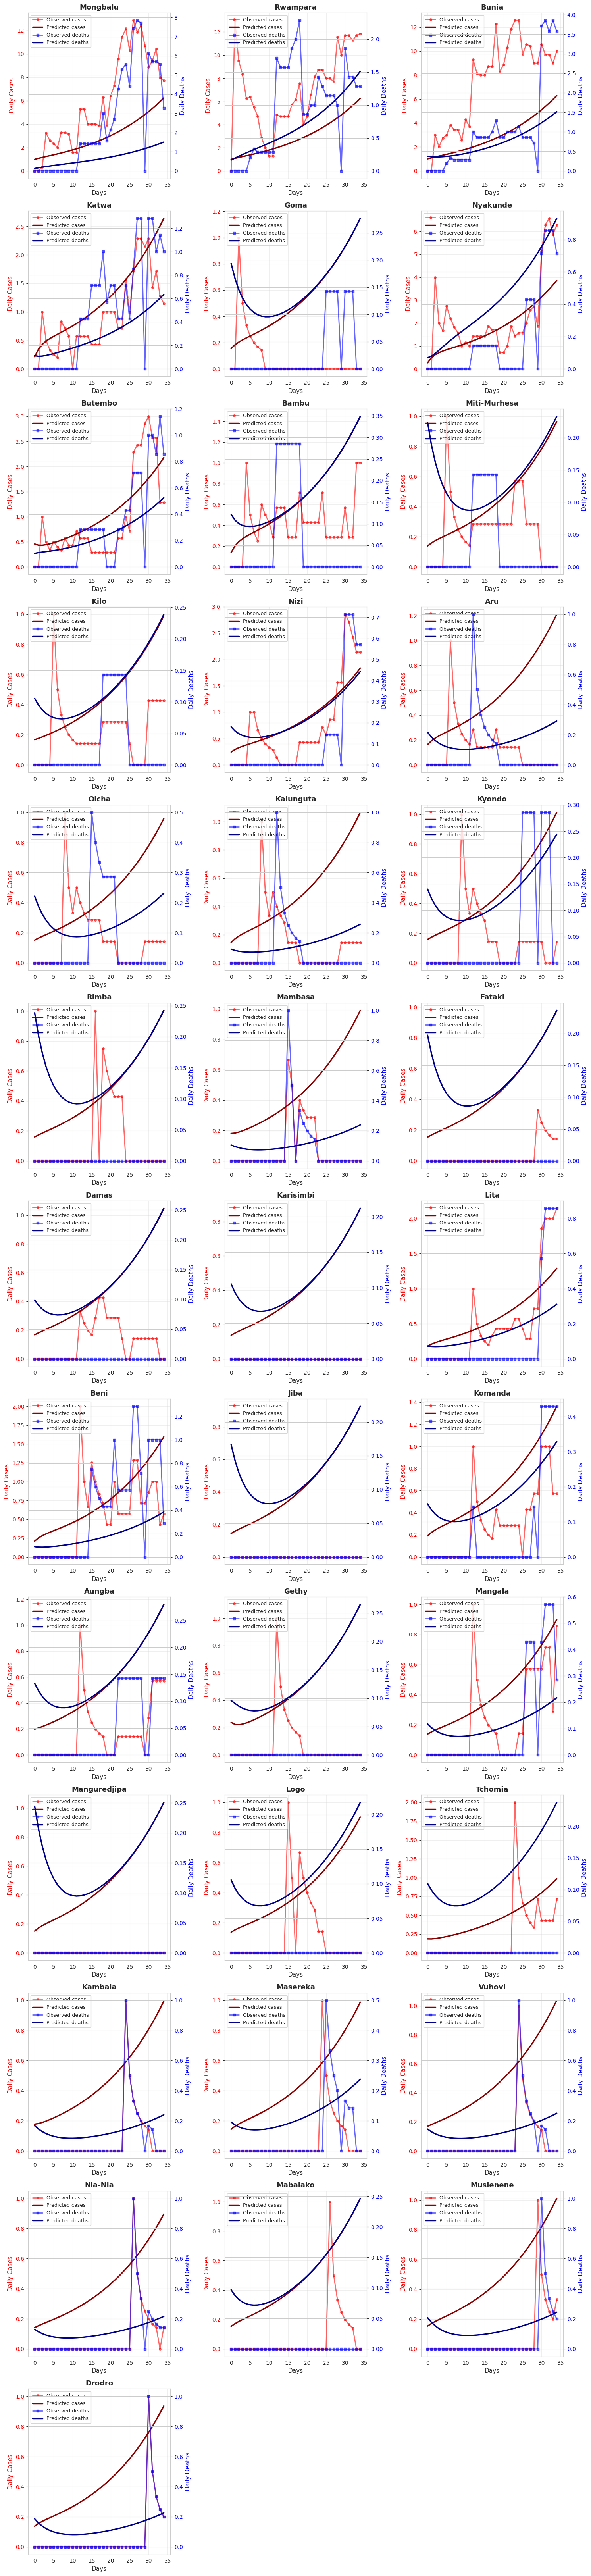


GOODNESS-OF-FIT METRICS

Mongbalu:
  Cases:  RMSE = 4.12,  Correlation = 0.8195
  Deaths: RMSE = 2.93,  Correlation = 0.7930

Rwampara:
  Cases:  RMSE = 4.79,  Correlation = 0.6597
  Deaths: RMSE = 0.63,  Correlation = 0.5078

Bunia:
  Cases:  RMSE = 5.17,  Correlation = 0.7291
  Deaths: RMSE = 0.95,  Correlation = 0.8132

Katwa:
  Cases:  RMSE = 0.53,  Correlation = 0.7817
  Deaths: RMSE = 0.40,  Correlation = 0.7966

Goma:
  Cases:  RMSE = 0.61,  Correlation = -0.4184
  Deaths: RMSE = 0.13,  Correlation = 0.5445

Nyakunde:
  Cases:  RMSE = 1.32,  Correlation = 0.7044
  Deaths: RMSE = 0.30,  Correlation = 0.7813

Butembo:
  Cases:  RMSE = 0.61,  Correlation = 0.7565
  Deaths: RMSE = 0.26,  Correlation = 0.8558

Bambu:
  Cases:  RMSE = 0.44,  Correlation = 0.3479
  Deaths: RMSE = 0.19,  Correlation = -0.2613

Miti-Murhesa:
  Cases:  RMSE = 0.40,  Correlation = -0.1457
  Deaths: RMSE = 0.14,  Correlation = -0.4696

Kilo:
  Cases:  RMSE = 0.37,  Correlation = 0.1963
  Deaths: RMSE = 0.1

In [89]:
print("\n" + "█"*80)
print("█" + " "*78 + "█")
print("█" + " "*20 + "MULTI-PATCH EBOLA FITTING WITH FLOWMINDER" + " "*16 + "█")
print("█" + " "*78 + "█")
print("█"*80)

# ─────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD EPIDEMIOLOGICAL DATA
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 1: LOAD EPIDEMIOLOGICAL DATA")
print("="*80)

# EDIT THIS PATH TO YOUR DATA FILE
data_file = '/home/moez/Desktop/data_thiery/data ebola/smoothed_incidence_multipatch.csv'

data_dict, obs_cases, obs_deaths, patch_names, obs_dates = load_multipath_ebola_data(data_file)

n_patches = len(patch_names)
n_days = obs_cases.shape[1]
DATA_START = obs_dates[0]

print(f"\n✓ Data loaded successfully")
print(f"  Patches: {patch_names}")
print(f"  Time points: {n_days}")
print(f"  Date range: {DATA_START.date()} to {obs_dates[-1].date()}")

# Summary statistics
print(f"\n  Summary statistics:")
for i, patch in enumerate(patch_names):
    total_cases = np.sum(obs_cases[i, :])
    total_deaths = np.sum(obs_deaths[i, :])
    peak_cases = np.max(obs_cases[i, :])
    peak_deaths = np.max(obs_deaths[i, :])
    
    print(f"\n  {patch}:")
    print(f"    Total cases:       {total_cases:.0f}")
    print(f"    Total deaths:      {total_deaths:.0f}")
    print(f"    Peak daily cases:  {peak_cases:.0f}")
    print(f"    Peak daily deaths: {peak_deaths:.0f}")

# ─────────────────────────────────────────────────────────────────────────
# STEP 2: LOAD MOBILITY DATA
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 2: LOAD MOBILITY DATA")
print("="*80)

# EDIT THESE PATHS TO YOUR FLOWMINDER FILES
inflow_file = 'https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/flowminder/processed/flowminder__inflow__static.matrix.csv'
outflow_file = 'https://raw.githubusercontent.com/INRB-UMIE/BDBV2026-Data/refs/heads/main/data/flowminder/processed/flowminder__outflow__static.matrix.csv'

try:
    U_mobility, U_patch_names = load_flowminder_inflow_outflow(
        inflow_file, outflow_file, method='average'
    )
    
    # Validate
    validate_mobility_matrix(U_mobility)
    
    # Print
    print_mobility_matrix(U_mobility, U_patch_names)
    
    # Align with epidemiological data
    if U_patch_names != patch_names:
        print(f"\n⚠ Aligning mobility matrix to match epidemiological patch order")
        reorder_idx = [U_patch_names.index(p) for p in patch_names]
        U_mobility = U_mobility[np.ix_(reorder_idx, reorder_idx)]
        print(f"✓ Reordered successfully")
    
except Exception as e:
    print(f"\n⚠ Could not load Flowminder data: {e}")
    print(f"Using identity matrix (no mobility)")
    U_mobility = np.eye(n_patches)

# ─────────────────────────────────────────────────────────────────────────
# STEP 3: SET POPULATION AND PARAMETERS
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 3: POPULATION AND PARAMETERS")
print("="*80)

# Set population per patch (EDIT as needed)
N_patches = load_population_data(
    '/home/moez/Desktop/data_thiery/data ebola/pop_data.csv',
    patch_names
)
print(f"\n✓ Population per patch:")
for i, patch in enumerate(patch_names):
    print(f"  {patch}: {N_patches[i]:.0f}")
print(f"  Total: {N_patches.sum():.0f}")

# Set parameters
r = 1.0  # Isolation parameter
use_patch_specific_transmission = False
likelihood = 'poisson'  # 'nb', 'poisson', 'gaussian', 'mse'
likelihood_k = 10.0

print(f"\nModel Configuration:")
print(f"  Isolation parameter (r): {r}")
print(f"  Patch-specific transmission: {use_patch_specific_transmission}")
print(f"  Likelihood: {likelihood} (k={likelihood_k})")

# ─────────────────────────────────────────────────────────────────────────
# STEP 4: RUN CALIBRATION
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 4: CALIBRATION")
print("="*80)

result = run_calibration(
    n_patches, N_patches, U_mobility,
    obs_cases, obs_deaths, n_days,
    r=r, likelihood=likelihood, likelihood_k=likelihood_k,
    maxiter=2000, popsize=15, seed=42
)

best_params = result.x

# ─────────────────────────────────────────────────────────────────────────
# STEP 5: VALIDATION AND PLOTTING
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 5: VALIDATION AND PLOTTING")
print("="*80)

pred_cases, pred_deaths = validate_and_plot(
    best_params, n_patches, patch_names, N_patches, U_mobility,
    obs_cases, obs_deaths, n_days, r
)

# ─────────────────────────────────────────────────────────────────────────
# STEP 6: PRINT RESULTS SUMMARY
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 6: RESULTS SUMMARY")
print("="*80)

print_results_summary(best_params, n_patches, patch_names, r)

# ─────────────────────────────────────────────────────────────────────────
# STEP 7: SAVE RESULTS
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STEP 7: SAVING RESULTS")
print("="*80)

# Save parameters to file
results_dict = {
    'patches': patch_names,
    'n_patches': n_patches,
    'n_days': n_days,
    'best_nll': result.fun,
    'best_params': best_params,
    'timestamp': datetime.now().isoformat()
}

import json
with open('ebola_calibration_results.json', 'w') as f:
    json.dump({k: v if not isinstance(v, np.ndarray) else v.tolist() 
               for k, v in results_dict.items()}, f, indent=2)

print(f"\n✓ Results saved to: ebola_calibration_results.json")
print(f"✓ Plot saved to: multipath_ebola_fit.png")

print("\n" + "█"*80)
print("█" + " "*78 + "█")
print("█" + " "*25 + "CALIBRATION COMPLETE!" + " "*31 + "█")
print("█" + " "*78 + "█")
print("█"*80)